<a href="https://colab.research.google.com/github/sarangis/python_learning/blob/main/M3_AST_01_Model_Parameters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Programme in Agentic and Generative AI
## A Programme by IISc and TalentSprint
## Assignment: Model Parameters

## Learning Objectives

At the end of the experiment, you will be able to

* load a pre-trained language model (e.g., `gemma-2b`) using Hugging Face
* extract and visualize logits and token probabilities from the model
* understand and apply temperature scaling to control randomness
* implement and analyze top-k and top-p (nucleus) sampling techniques
* visualize probability distributions to interpret model behavior
* generate text using different decoding strategies and compare outputs
* control the length of generated text using max tokens

# Model Parameters in Generative AI

Model parameters (also called **generation parameters**) control how a language model produces output. These settings do **not change the model itself**, but influence how it selects the next token during text generation.

---

## Why Model Parameters Matter

Generation parameters allow users to:

- control the **creativity vs accuracy** of responses  
- adjust the **length and style** of output  
- improve **consistency or diversity** depending on the task  
- tailor responses for **different use cases** (e.g., coding vs storytelling)  

Even small changes in these parameters can significantly impact the generated output.

---

## Key Model Parameters

### 1. Temperature

**Definition:**  
Controls the randomness of the output by scaling the probability distribution of tokens.

**How it works:**
- Low temperature → sharper probabilities → predictable output  
- High temperature → flatter probabilities → more diverse output  

**Typical range:** `0.0 – 1.5`

**Example:**
- `0.2` → factual, deterministic  
- `0.7` → balanced  
- `1.2` → creative, varied  

---

### 2. Top-p (Nucleus Sampling)

**Definition:**  
Selects the smallest set of tokens whose cumulative probability exceeds a threshold `p`.

**How it works:**
- Tokens are sorted by probability  
- Only top tokens contributing to `p` are considered  

**Typical range:** `0.7 – 1.0`

**Example:**
- `0.9` → consider tokens covering 90% probability  
- `0.3` → very limited choices  

---

### 3. Top-k

**Definition:**  
Restricts the model to choose from the top `k` most probable tokens.

**How it works:**
- Only top `k` tokens are considered  
- Remaining tokens are ignored  

**Typical values:** `10 – 100`

**Example:**
- `k = 1` → greedy (most probable token only)  
- `k = 50` → more diverse output  

---

### 4. Max Tokens (max_new_tokens)

**Definition:**  
Limits the number of tokens the model can generate in a response.

**Purpose:**
- controls response length  
- prevents excessively long outputs  
- helps manage computation and cost  

**Example:**
- `10` → short response  
- `100` → detailed response  

---

## How These Parameters Work Together

During generation:

1. Model produces **logits (raw scores)**  
2. Apply **temperature scaling**  
3. Convert to probabilities using softmax  
4. Apply **top-k / top-p filtering**  
5. Sample next token  
6. Repeat until **max tokens reached**  

---

## Best Practices

- Use **low temperature (0–0.3)** for:
  - factual answers  
  - coding  
  - structured outputs  

- Use **moderate temperature (0.5–0.8)** for:
  - general tasks  
  - business use cases  

- Use **high temperature (>1.0)** for:
  - creative writing  
  - brainstorming  

- Avoid using **aggressive top-k and top-p together** unless needed  

- Always set **max tokens** to control output length  

---

## Summary

Model parameters provide a powerful way to control AI outputs without retraining the model. By adjusting these settings, users can make the model more **accurate, creative, concise, or diverse**, depending on the task.

### Setup Steps:

In [ ]:
#@title Please enter your registration id to start: { run: "auto", display-mode: "form" }
Id = "" #@param {type:"string"}

In [ ]:
#@title Please enter your password (your registered phone number) to continue: { run: "auto", display-mode: "form" }
password = "" #@param {type:"string"}

In [ ]:
#@title Run this cell to complete the setup for this Notebook
from IPython import get_ipython
from IPython.display import HTML, display

ipython = get_ipython()

notebook= "M3_AST_01_Model_Parameters" #name of the notebook

batchId = "IISC-AC-GENAI-02"


def print_message(message: str, color: str = "red"):
    display(HTML(f"<span style='color:{color};'>{message}</span>"))

def setup():
#  ipython.magic("sx pip3 install torch")

    from IPython.display import HTML, display
    display(HTML('<script src="https://dashboard.talentsprint.com/submissions/record_ip.html?traineeId={0}&recordId={1}"></script>'.format(getId(),submission_id)))
    print("Setup completed successfully")
    return

def submit_notebook():
    ipython.magic("notebook -e "+ notebook + ".ipynb")

    import requests, json, base64, datetime

    url = "https://dashboard.talentsprint.com/xp/app/save_notebook_attempts"
    if not submission_id:
      data = {"id" : getId(), "notebook" : notebook, "mobile" : getPassword(), "batch" : batchId}
      r = requests.post(url, data = data)
      r = json.loads(r.text)

      if r["status"] == "Success":
          return r["record_id"]
      elif "err" in r:
        print_message(r["err"])
        return None
      else:
        print_message("Something is wrong, the notebook will not be submitted for grading")
        return None

    elif getAnswer() and getComplexity() and getAdditional() and getConcepts() and getComments() and getMentorSupport():
      f = open(notebook + ".ipynb", "rb")
      file_hash = base64.b64encode(f.read())

      data = {"complexity" : Complexity, "additional" :Additional,
              "concepts" : Concepts, "record_id" : submission_id,
              "answer" : Answer, "id" : Id, "file_hash" : file_hash,
              "notebook" : notebook,
              "feedback_experiments_input" : Comments,
              "feedback_mentor_support": Mentor_support,
              "batch" : batchId
            }
      r = requests.post(url, data = data)
      r = json.loads(r.text)
      if "err" in r:
        print(r["err"])
        return None
      else:
        print("Your submission is successful.")
        print("Ref Id:", submission_id)
        print("Date of submission: ", r["date"])
        print("Time of submission: ", r["time"])
        print("View your submissions: https://learn-iisc.talentsprint.com/notebook_submissions")
        #print("For any queries/discrepancies, please connect with mentors through the chat icon in LMS dashboard.")
        return submission_id
    else: submission_id


def getAdditional():
  try:
    if not Additional:
      raise NameError
    else:
      return Additional
  except NameError:
    print ("Please answer Additional Question")
    return None

def getComplexity():
  try:
    if not Complexity:
      raise NameError
    else:
      return Complexity
  except NameError:
    print ("Please answer Complexity Question")
    return None

def getConcepts():
  try:
    if not Concepts:
      raise NameError
    else:
      return Concepts
  except NameError:
    print ("Please answer Concepts Question")
    return None


# def getWalkthrough():
#   try:
#     if not Walkthrough:
#       raise NameError
#     else:
#       return Walkthrough
#   except NameError:
#     print ("Please answer Walkthrough Question")
#     return None

def getComments():
  try:
    if not Comments:
      raise NameError
    else:
      return Comments
  except NameError:
    print ("Please answer Comments Question")
    return None


def getMentorSupport():
  try:
    if not Mentor_support:
      raise NameError
    else:
      return Mentor_support
  except NameError:
    print ("Please answer Mentor support Question")
    return None

def getAnswer():
  try:
    if not Answer:
      raise NameError
    else:
      return Answer
  except NameError:
    print ("Please answer Question")
    return None


def getId():
  try:
    return Id if Id else None
  except NameError:
    return None

def getPassword():
  try:
    return password if password else None
  except NameError:
    return None

submission_id = None
### Setup
if getPassword() and getId():
  submission_id = submit_notebook()
  if submission_id:
    setup()
else:
  print ("Please complete Id and Password cells before running setup")

### Importing Required Library

In [ ]:
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

### Read Hugging Face Token

**Hugging Face**

- It is an open-source AI platform that provides tools, libraries, and pre-trained models for building applications with machine learning and natural language processing.

- It is best known for its **Transformers library** (`transformers`), which allows developers to easily use state-of-the-art models (like BERT, GPT, and Gemma) for tasks such as text generation, classification, and translation.

- Hugging Face also offers a **model hub** where thousands of models and datasets are shared, enabling rapid development and experimentation in AI.


**Hugging Face Access Token**

- It is a secure authentication key that allows users to access resources on the Hugging Face platform, such as private or gated models (e.g., Gemma), datasets, and APIs.

- It acts like a password for programmatic access, enabling users to download models, and interact with the Hugging Face Hub.

- The token can be generated from the user’s Hugging Face account settings and is typically used via CLI login, environment variables, or directly in code, while ensuring it is kept confidential and not exposed publicly.

**How to Get a Hugging Face Access Token**

Follow these steps:

1. Go to the Hugging Face website: https://huggingface.co  
2. Sign in (or create a new **Free-tier** account)  
3. Click on your **profile icon → Settings**  
4. Navigate to **Access Tokens**  
5. Click **“Create new token”**  
6. Provide:
   - **Token type**: Write  
   - **Token name** (e.g., `my_token`)  
7. Click **Craete token**  
8. Copy and store the token securely in Google Colab Secrets

In [ ]:
# First, add your HuggingFace Token (with Write access) to Google Colab Secrets
# Then, load the token using below code

from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
login(token = hf_token)

# **Next Token Prediction**

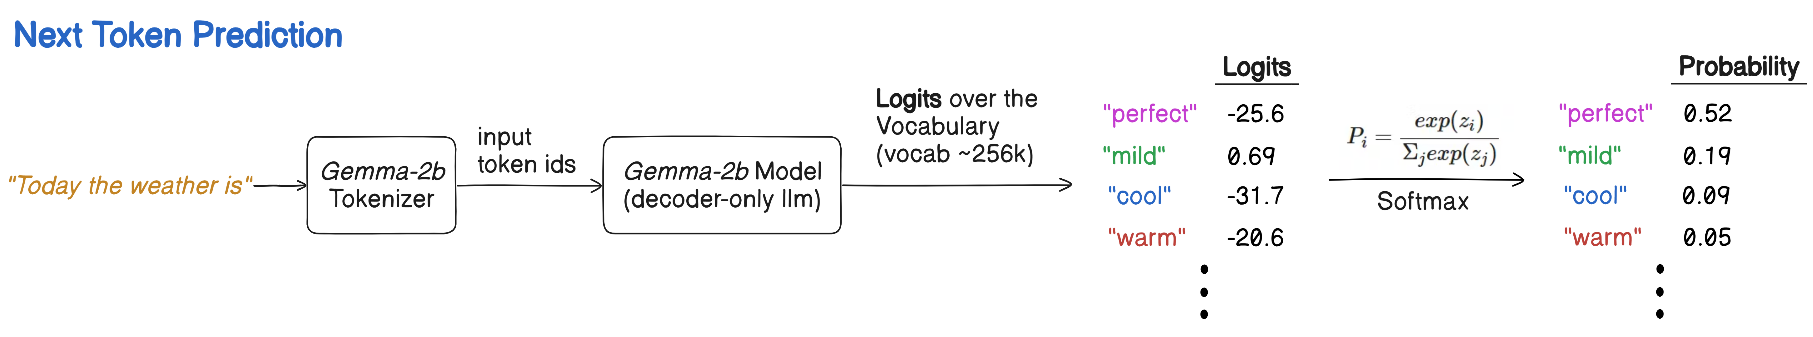

*(For enlarged view, right click on image and open it in new tab.)*

### Load Tokenizer (associated with Gemma model)

**Gemma Model**

- Gemma is a family of lightweight, state-of-the-art open models from Google, built from the same research and technology used to create the Gemini models.

- They are text-to-text, ***decoder-only large language models***, available in English, with open weights, pre-trained variants, and instruction-tuned variants.

- Gemma models are well-suited for a variety of text generation tasks, including question answering, summarization, and reasoning.

- Their relatively small size makes it possible to deploy them in environments with limited resources such as a laptop, desktop or your own cloud infrastructure, democratizing access to state of the art AI models and helping foster innovation for everyone.

To know more about the Gemma model, refer [here](https://huggingface.co/google/gemma-2b).

**Tokenizer**

- A component in NLP that ***converts raw text into smaller units called tokens*** (such as words, subwords, or characters) that a model can understand.

- Since language models operate on numerical data, the tokenizer ***maps these tokens to unique token IDs***, enabling the model to process input and generate output.

- It also performs the reverse operation—converting token IDs back into human-readable text.

* Load the tokenizer - `"google/gemma-2b"`

  - <font color="#990000">NOTE that `"google/gemma-2b"` is a Gated model. You will be required to raise a request before using this model.</font>

  - <font color="#990000">You can login to your account on HuggingFace and then go to https://huggingface.co/google/gemma-2b, click on **"Accept License"** and follow the prompts.
  
  - Requests are approved instantly.</font>


In [ ]:
# Load Tokenizer

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("google/gemma-2b")

In [ ]:
# Check Vocabulary
vocabulary = tokenizer.vocab

len(vocabulary)

In [ ]:
list(vocabulary.keys())[10000:10020]

In [ ]:
# Raw text -> Token Ids

tokens = tokenizer.encode("Today the weather is")
tokens

In [ ]:
# Token Ids -> Tokens

tokenizer.convert_ids_to_tokens(tokens)

In [ ]:
# Token Ids -> Raw text

tokenizer.decode(tokens)

## Load Gemma Model

In [ ]:
# Load Model

model = AutoModelForCausalLM.from_pretrained("google/gemma-2b",
                                             device_map="auto"       # to load the entire model on the GPU if its available
                                             )


In [ ]:
print(model)

In [ ]:
# Tokenize the given text prompt

prompt = "Complete this sentence: Today the weather is"

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

inputs

In [ ]:
tokenizer.decode(inputs['input_ids'])

**Get Logits from model**

- **Logits** are the raw, unnormalized output scores produced by a language model before applying any probability function.

- They represent how strongly the model favors each possible token in the vocabulary for the next position.

- These values can be positive or negative and do not sum to 1.

- To convert logits into meaningful probabilities, a softmax function is applied.

In [ ]:
# Get logits for a prompt

# Run the model in inference mode (no gradient tracking) to obtain raw outputs (logits)
with torch.no_grad():
    outputs = model(**inputs)

# 'outputs' contains the model’s predictions, including logits for each token in the sequence
outputs

In [ ]:
# Extract logits from model output

logits = outputs.logits

logits

In [ ]:
print(logits.shape)       # shape: (batch_size, sequence_length, vocab_size)

In [ ]:
# Extract logits corresponding to the NEXT token prediction (last position in the sequence)
next_token_logits = logits[0, -1, :]

# Shape represents the scores for all tokens in the vocabulary
next_token_logits.shape

In [ ]:
next_token_logits

In [ ]:
# Convert logits → probabilities (Softmax)

import torch.nn.functional as F

probs = F.softmax(next_token_logits, dim=-1)

probs.shape

In [ ]:
# Probabilities
probs

In [ ]:
# Probabilities - should sum to ~1
probs.sum()

In [ ]:
# Sort based on probabilities

top_probs, top_indices = torch.sort(probs, descending=True)

top_probs, top_indices

In [ ]:
# Top 15 probable tokens

top_tokens = tokenizer.convert_ids_to_tokens(top_indices.tolist())
top_tokens[:15]

In [ ]:
top_probs[0].item()

In [ ]:
# Show tokens and their probabilities

print("Token             Probability")
print("="*40)
for i in range(15):
    print(f"{top_tokens[i]:15s} → {top_probs[i].item():.4f}")

### Save Logits, Top probabilities, Top tokens (for reproducing the results)

In [ ]:
# Round off the logits to 4-decimal before saving in file
round_logits = [round(logit.item(),4) for logit in next_token_logits]

In [ ]:
len(round_logits)

In [ ]:
round_logits[:5]

In [ ]:
# Round off the probabilities to 4-decimal before saving in file
round_probs = [round(prob.item(),4) for prob in top_probs]
len(round_probs), round_probs[:5]

In [ ]:
top_tokens[:5]

In [ ]:
# This code uses Python’s pickle module to save model-related data (logits, top probabilities, and top tokens)
# into a file for later use.
# It first organizes the data into a dictionary, then opens a file named gemma_token_data.pkl
# in binary write mode and serializes (dumps) the data into it.
# This is useful for persisting intermediate results so they can be reloaded without recomputing.

import pickle

data_to_save = {
    'logits': round_logits,
    'top_probs': round_probs,
    'top_tokens': top_tokens
}

with open('gemma_token_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("Logits, Top-probabilities, and Top-tokens saved to 'gemma_token_data.pkl'")

In [ ]:
# Load data from pickle file
import pickle

with open('gemma_token_data.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

print("Data loaded successfully:")
print(loaded_data.keys())

In [ ]:
len(loaded_data['logits'])

In [ ]:
loaded_data['logits'][:5]

In [ ]:
loaded_data['top_probs'][:5]

In [ ]:
loaded_data['top_tokens'][:5]

### Create a Bar plot to show probabilities of top 15 tokens

In [ ]:
logits = loaded_data['logits']
top_probs = loaded_data['top_probs']
top_tokens = loaded_data['top_tokens']

In [ ]:
# Convert logits to a PyTorch tensor with bfloat16 precision (reduces memory usage and matches model dtype)
next_token_logits = torch.tensor(logits, dtype=torch.bfloat16)

# Display the converted logits tensor
next_token_logits

In [ ]:
# Similarly, convert probabilities to a PyTorch tensor with bfloat16 precision
top_probs = torch.tensor(top_probs, dtype=torch.bfloat16)

In [ ]:
top_tokens[:15]

In [ ]:
[round(prob.item(),4) for prob in top_probs[:15]]

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

x = top_tokens[:15]
y = [round(prob.item(),4) for prob in top_probs[:15]]

plt.figure(figsize=(10, 5))
sns.barplot(x=x, y=y, palette='plasma', hue=x)
plt.title('Top 15 Next Token Probabilities')
plt.xlabel('Token')
plt.ylabel('Probability')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Temperature**

Controls the randomness of the output by scaling the probability distribution of tokens.

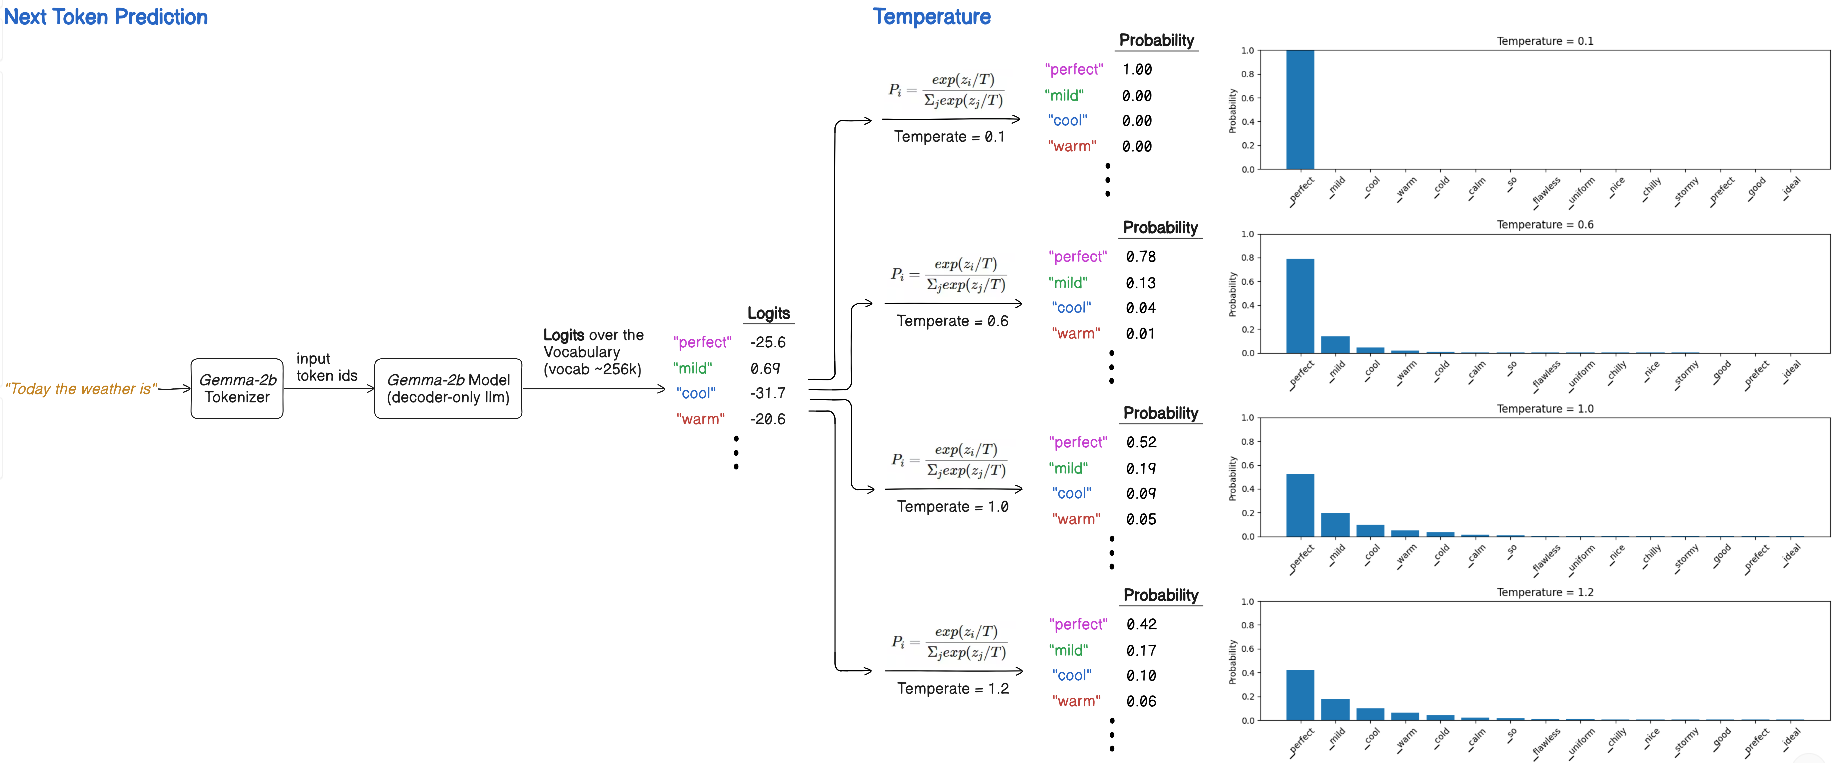

*(For enlarged view, right click on image and open it in new tab.)*

In [ ]:
import torch.nn.functional as F

temperature = 1      # <--- this value can be changed to control randomness

# Apply temperature scaling
scaled_logits = next_token_logits / temperature

# Convert to probabilities
probs_t1 = F.softmax(scaled_logits, dim=-1)

probs_t1.shape

In [ ]:
probs_t1

In [ ]:
probs_t1.sum()

In [ ]:
top_probs_t1, top_indices_t1 = torch.sort(probs_t1, descending=True)

top_probs_t1, top_indices_t1

In [ ]:
top_tokens_t1 = tokenizer.convert_ids_to_tokens(top_indices_t1.tolist())
top_tokens_t1[:15]

In [ ]:
print("Token             Probability (t=1)")
print("="*40)
for i in range(15):
    print(f"{top_tokens_t1[i]:15s} → {top_probs_t1[i].item():.4f}")

In [ ]:
# Create a function to get probable tokens & probabilities for varying temperature value

def get_probs_after_temp(logits, temperature=1.0):
    if temperature == 0.0:
        temperature = 1e-9        # to prevent division by 0
    scaled_logits = logits / temperature
    probs = F.softmax(scaled_logits, dim=-1)
    top_probs, top_indices = torch.sort(probs, descending=True)
    top_tokens = tokenizer.convert_ids_to_tokens(top_indices.tolist())
    return top_probs, top_tokens

In [ ]:
# Varying temperature to 0.1, 0.6, 1.2

top_probs_t01, top_tokens_t01 = get_probs_after_temp(logits=next_token_logits, temperature=0.1)
top_probs_t06, top_tokens_t06 = get_probs_after_temp(logits=next_token_logits, temperature=0.6)
top_probs_t12, top_tokens_t12 = get_probs_after_temp(logits=next_token_logits, temperature=1.2)

In [ ]:
print("Token             Probability (t=0.1)    Probability (t=0.6)    Probability (t=1)    Probability (t=1.2)")
print("="*110)
for i in range(15):
    print(f"{top_tokens_t01[i]:15s} → {top_probs_t01[i].item():.4f} {' '*15} {top_probs_t06[i].item():.4f} {' '*15} {top_probs_t1[i].item():.4f} {' '*15} {top_probs_t12[i].item():.4f}")

In [ ]:
# Visualize in Bar plot

import matplotlib.pyplot as plt

# Number of tokens to plot
n = 15

# Create vertical subplots (4 rows, 1 column)
fig, axes = plt.subplots(4, 1, figsize=(10, 12))

# -------- Temperature = 0.1 --------
x_t01 = top_tokens_t01[:n]
y_t01 = [round(prob.item(),4) for prob in top_probs_t01[:n]]
axes[0].bar(x_t01, y_t01)
axes[0].set_title("Temperature = 0.1")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# -------- Temperature = 0.6 --------
x_t06 = top_tokens_t06[:n]
y_t06 = [round(prob.item(),4) for prob in top_probs_t06[:n]]
axes[1].bar(x_t06, y_t06)
axes[1].set_title("Temperature = 0.6")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

# -------- Temperature = 1.0 --------
x_t1 = top_tokens_t1[:n]
y_t1 = [round(prob.item(),4) for prob in top_probs_t1[:n]]
axes[2].bar(x_t1, y_t1)
axes[2].set_title("Temperature = 1.0")
axes[2].set_ylabel("Probability")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)

# -------- Temperature = 1.2 --------
x_t12 = top_tokens_t12[:n]
y_t12 = [round(prob.item(),4) for prob in top_probs_t12[:n]]
axes[3].bar(x_t12, y_t12)
axes[3].set_title("Temperature = 1.2")
axes[3].set_ylabel("Probability")
axes[3].set_ylim(0, 1)
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Save the different token probabilities in a Dataframe

df = pd.DataFrame({
    "token": top_tokens_t01[:15],
    "p(t=0.1)": [round(prob.item(),4) for prob in top_probs_t01[:15]],
    "p(t=0.6)": [round(prob.item(),4) for prob in top_probs_t06[:15]],
    "p(t=1)": [round(prob.item(),4) for prob in top_probs_t1[:15]],
    "p(t=1.2)": [round(prob.item(),4) for prob in top_probs_t12[:15]]
})
df

In [ ]:
# Visualize side-by-side Bar plot

import numpy as np
probabilities = ["p(t=0.1)", "p(t=0.6)", "p(t=1)", "p(t=1.2)"]

# Create numeric positions for token on the x-axis
x = np.arange(len(df['token']))  # [0, 1, 2, ..., n-1]

# Set the width of each bar
# Since multiple probabilities are plotted per token, small width avoids overlap
width = 0.12

# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(15, 6))

# Loop through each probabilities and plot its bars
for i, prob in enumerate(probabilities):

    # Shift each probability slightly on the x-axis so bars appear side-by-side
    ax.bar(x + i * width, df[prob], width, label=prob)


ax.set_xlabel('Token')                              # Set x-axis label
ax.set_ylabel('Probability')                        # Set y-axis label
ax.set_title('Comparative Probability per Token')   # Set chart title
ax.set_xticks(x + width * 2)                        # Center x-axis ticks under grouped bars
ax.set_xticklabels(df['token'], rotation=45)         # Set Token labels and rotate for readability
ax.legend()                                  # Display legend to identify each probability
plt.tight_layout()                           # Adjust layout to prevent label cutoff
plt.show()                                   # Display the plot

# **Top-k**

Restricts the model to choose from the top k most probable tokens.

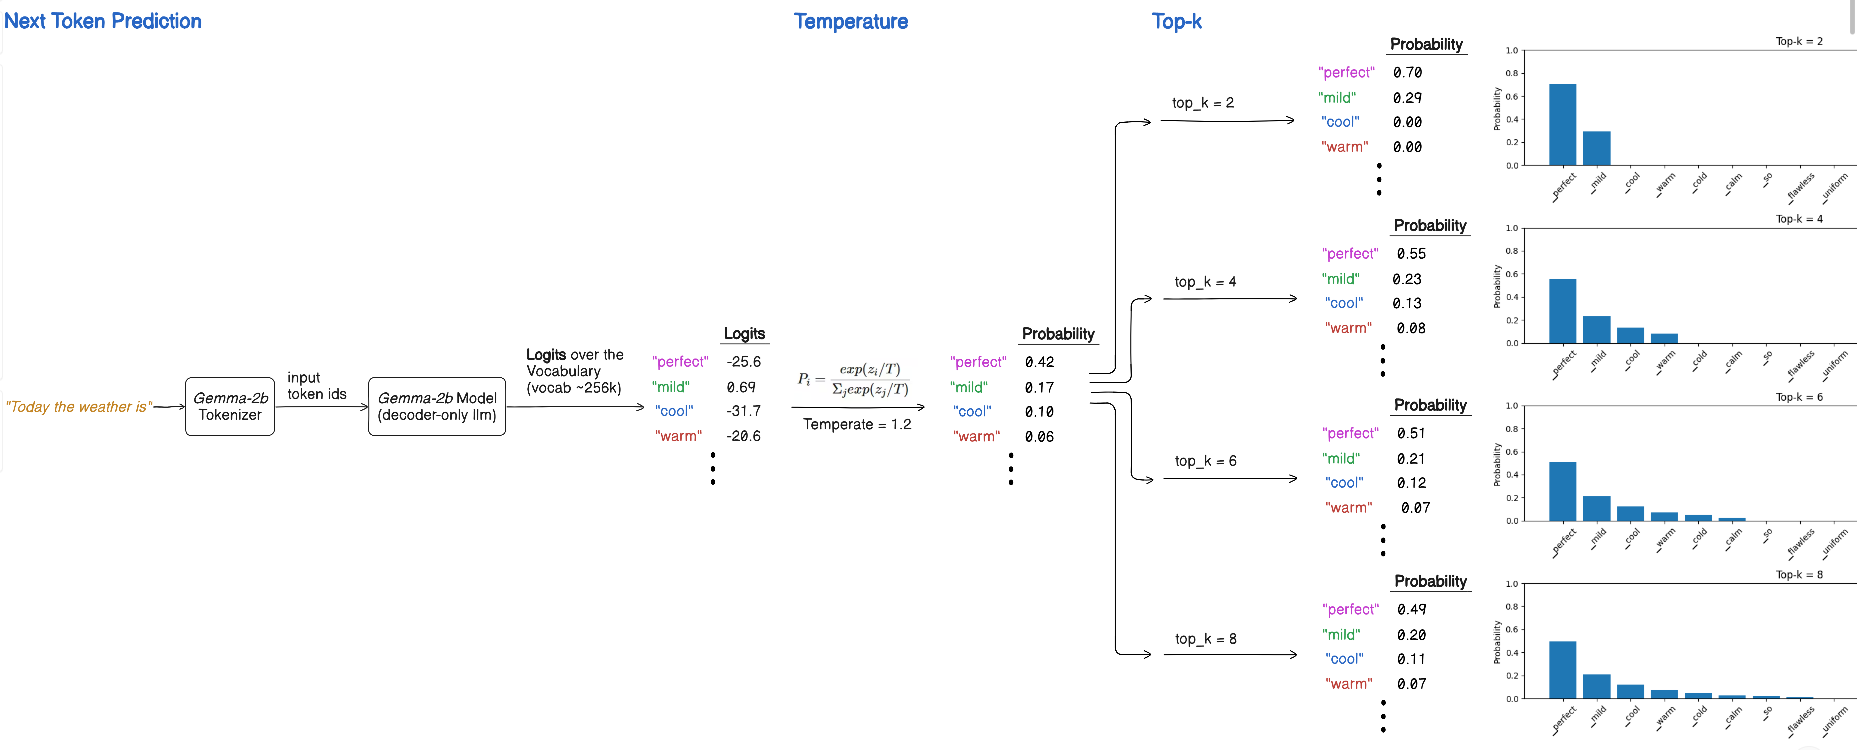

*(For enlarged view, right click on image and open it in new tab.)*

In [ ]:
# Create a function to get probable tokens & probabilities for varying top_k value

import torch
import torch.nn.functional as F

def get_probs_after_top_k(logits, temperature=1.0, top_k=None):
    if temperature == 0.0:
        temperature = 1e-9        # to prevent division by 0

    # Apply temperature
    scaled_logits = logits / temperature

    # Softmax → probabilities
    probs = F.softmax(scaled_logits, dim=-1)

    # Sort probabilities (descending)
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)

    # Apply top-k filtering
    if top_k is not None and top_k > 0:
        top_k = min(top_k, sorted_probs.size(0))
        top_k_mask = torch.arange(sorted_probs.size(0), device=sorted_probs.device) < top_k
    else:
        top_k_mask = torch.ones_like(sorted_probs, dtype=torch.bool)

    # Keep only tokens allowed by top-k
    final_mask = top_k_mask
    final_mask[0] = True   # ensure at least one token remains

    filtered_probs = sorted_probs * final_mask

    # Renormalize After Filtering
    # Renormalization is required after top-k filtering if you want to use the filtered values
    # as a valid probability distribution for sampling (selecting/picking the next token).
    filtered_probs = filtered_probs / filtered_probs.sum()

    # Convert indices → tokens
    filtered_tokens = tokenizer.convert_ids_to_tokens(sorted_indices.tolist())

    return filtered_probs, filtered_tokens

In [ ]:
# Keeping the temperature=1.2, and Varying top_k to 2, 4, 6, 8

top_probs_top_k2, top_tokens_top_k2 = get_probs_after_top_k(logits=next_token_logits,  temperature=1.2, top_k=2)
top_probs_top_k4, top_tokens_top_k4 = get_probs_after_top_k(logits=next_token_logits,  temperature=1.2, top_k=4)
top_probs_top_k6, top_tokens_top_k6 = get_probs_after_top_k(logits=next_token_logits,  temperature=1.2, top_k=6)
top_probs_top_k8, top_tokens_top_k8 = get_probs_after_top_k(logits=next_token_logits,  temperature=1.2, top_k=8)

In [ ]:
top_probs_top_k2

In [ ]:
print("Token             Probability (top_k=2)    Probability (top_k=4)    Probability (top_k=6)    Probability (top_k=8)")
print("="*118)
for i in range(15):
    print(f"{top_tokens_top_k2[i]:15s} → {top_probs_top_k2[i].item():.4f} {' '*17} {top_probs_top_k4[i].item():.4f} {' '*17} {top_probs_top_k6[i].item():.4f} {' '*17} {top_probs_top_k8[i].item():.4f}")

In [ ]:
# Visualize in Bar plot

import matplotlib.pyplot as plt

# Number of tokens to plot
n = 15

# Create vertical subplots (4 rows, 1 column)
fig, axes = plt.subplots(4, 1, figsize=(10, 12))

# -------- Top-k = 2 --------
x_t01 = top_tokens_top_k2[:n]
y_t01 = [round(prob.item(),4) for prob in top_probs_top_k2[:n]]
axes[0].bar(x_t01, y_t01)
axes[0].set_title("Top-k = 2")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# -------- Top-k = 4 --------
x_t06 = top_tokens_top_k4[:n]
y_t06 = [round(prob.item(),4) for prob in top_probs_top_k4[:n]]
axes[1].bar(x_t06, y_t06)
axes[1].set_title("Top-k = 4")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

# -------- Top-k = 6 --------
x_t1 = top_tokens_top_k6[:n]
y_t1 = [round(prob.item(),4) for prob in top_probs_top_k6[:n]]
axes[2].bar(x_t1, y_t1)
axes[2].set_title("Top-k = 6")
axes[2].set_ylabel("Probability")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)

# -------- Top-k = 8 --------
x_t12 = top_tokens_top_k8[:n]
y_t12 = [round(prob.item(),4) for prob in top_probs_top_k8[:n]]
axes[3].bar(x_t12, y_t12)
axes[3].set_title("Top-k = 8")
axes[3].set_ylabel("Probability")
axes[3].set_ylim(0, 1)
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Save the different token probabilities in a Dataframe

df["p(top_k=2)"] = [round(prob.item(),4) for prob in top_probs_top_k2[:15]]
df["p(top_k=4)"] = [round(prob.item(),4) for prob in top_probs_top_k4[:15]]
df["p(top_k=6)"] = [round(prob.item(),4) for prob in top_probs_top_k6[:15]]
df["p(top_k=8)"] = [round(prob.item(),4) for prob in top_probs_top_k8[:15]]

df

In [ ]:
# Visualize side-by-side Bar plot

import numpy as np
probabilities = ["p(top_k=2)", "p(top_k=4)", "p(top_k=6)", "p(top_k=8)"]

# Create numeric positions for token on the x-axis
x = np.arange(len(df['token']))  # [0, 1, 2, ..., n-1]

# Set the width of each bar
# Since multiple probabilities are plotted per token, small width avoids overlap
width = 0.12

# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(15, 6))

# Loop through each probabilities and plot its bars
for i, prob in enumerate(probabilities):

    # Shift each probability slightly on the x-axis so bars appear side-by-side
    ax.bar(x + i * width, df[prob], width, label=prob)


ax.set_xlabel('Token')                              # Set x-axis label
ax.set_ylabel('Probability')                        # Set y-axis label
ax.set_title('Comparative Probability per Token')   # Set chart title
ax.set_xticks(x + width * 2)                        # Center x-axis ticks under grouped bars
ax.set_xticklabels(df['token'], rotation=45)         # Set Token labels and rotate for readability
ax.legend()                                  # Display legend to identify each probability
plt.tight_layout()                           # Adjust layout to prevent label cutoff
plt.show()                                   # Display the plot

# **Top-p**

Selects the smallest set of tokens whose cumulative probability exceeds a threshold `p`.

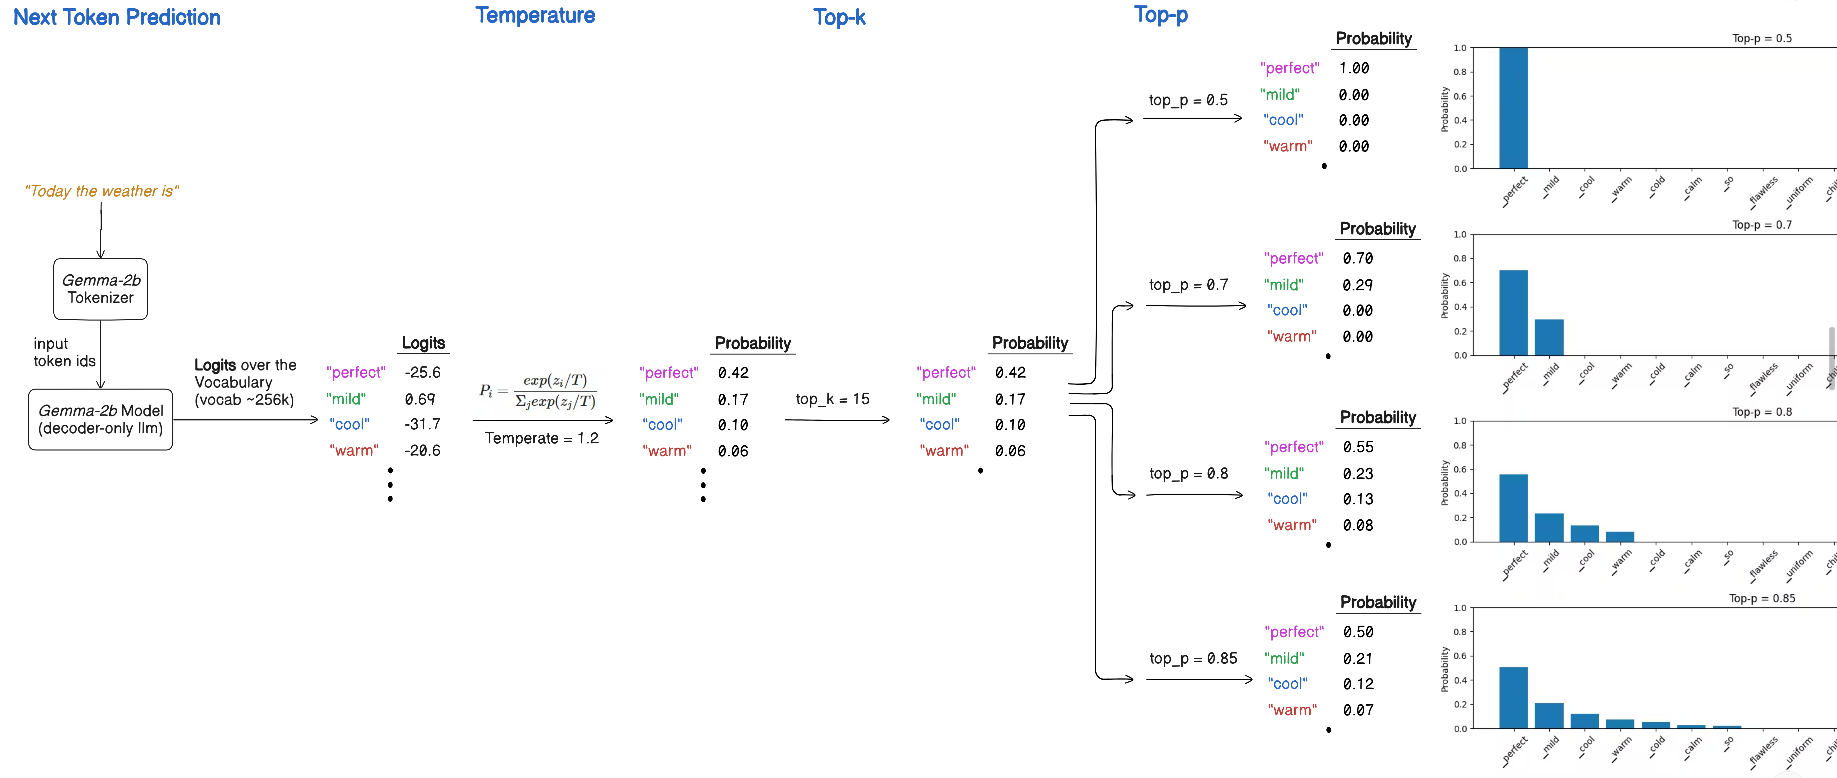

*(For enlarged view, right click on image and open it in new tab.)*

In [ ]:
# Create a function to get probable tokens & probabilities for varying top_p value

import torch
import torch.nn.functional as F

def get_probs_after_top_k_top_p(logits, temperature=1.0, top_k=None, top_p=1.0):
    if temperature == 0.0:
        temperature = 1e-9        # to prevent division by 0

    # Apply temperature
    scaled_logits = logits / temperature

    # Softmax → probabilities
    probs = F.softmax(scaled_logits, dim=-1)

    # Sort probabilities (descending)
    sorted_probs, sorted_indices = torch.sort(probs, descending=True)

    # Apply top-k filtering
    if top_k is not None and top_k > 0:
        top_k = min(top_k, sorted_probs.size(0))
        top_k_mask = torch.arange(sorted_probs.size(0), device=sorted_probs.device) < top_k
    else:
        top_k_mask = torch.ones_like(sorted_probs, dtype=torch.bool)

    # Compute cumulative probabilities
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

    # Apply top-p filtering
    if top_p < 1.0:
        top_p_mask = cumulative_probs <= top_p

        # Ensure at least one token is kept
        top_p_mask[0] = True
    else:
        top_p_mask = torch.ones_like(sorted_probs, dtype=torch.bool)

    # Keep only tokens allowed by both top-k and top-p
    final_mask = top_k_mask & top_p_mask
    final_mask[0] = True   # ensure at least one token remains

    filtered_probs = sorted_probs * final_mask

    # Renormalize After Filtering
    # Renormalization is required after top-k filtering if you want to use the filtered values
    # as a valid probability distribution for sampling (selecting/picking the next token).
    filtered_probs = filtered_probs / filtered_probs.sum()

    # Convert indices → tokens
    filtered_tokens = tokenizer.convert_ids_to_tokens(sorted_indices.tolist())

    return filtered_probs, filtered_tokens

In [ ]:
# Keeping the temperature=1.2 top_k=15, and Varying top_p to 0.5, 0.7, 0.8, 0.85

top_probs_top_p05, top_tokens_top_p05 = get_probs_after_top_k_top_p(logits=next_token_logits,  temperature=1.2, top_k=15, top_p=0.5)
top_probs_top_p07, top_tokens_top_p07 = get_probs_after_top_k_top_p(logits=next_token_logits,  temperature=1.2, top_k=15, top_p=0.7)
top_probs_top_p08, top_tokens_top_p08 = get_probs_after_top_k_top_p(logits=next_token_logits,  temperature=1.2, top_k=15, top_p=0.8)
top_probs_top_p085, top_tokens_top_p085 = get_probs_after_top_k_top_p(logits=next_token_logits,  temperature=1.2, top_k=15, top_p=0.85)

In [ ]:
top_probs_top_p08

In [ ]:
print("Token             Probability (top_p=0.5)    Probability (top_p=0.7)    Probability (top_p=0.8)    Probability (top_p=0.85)")
print("="*125)
for i in range(15):
    print(f"{top_tokens_top_p05[i]:15s} → {top_probs_top_p05[i].item():.4f} {' '*19} {top_probs_top_p07[i].item():.4f} {' '*19} {top_probs_top_p08[i].item():.4f} {' '*19} {top_probs_top_p085[i].item():.4f}")

In [ ]:
# Visualize is Bar plot

import matplotlib.pyplot as plt

# Number of tokens to plot
n = 15

# Create vertical subplots (4 rows, 1 column)
fig, axes = plt.subplots(4, 1, figsize=(10, 12))

# -------- Top-p = 0.5 --------
x_t01 = top_tokens_top_p05[:n]
y_t01 = [round(prob.item(),4) for prob in top_probs_top_p05[:n]]
axes[0].bar(x_t01, y_t01)
axes[0].set_title("Top-p = 0.5")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# -------- Top-p = 0.7 --------
x_t06 = top_tokens_top_p07[:n]
y_t06 = [round(prob.item(),4) for prob in top_probs_top_p07[:n]]
axes[1].bar(x_t06, y_t06)
axes[1].set_title("Top-p = 0.7")
axes[1].set_ylabel("Probability")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

# -------- Top-p = 0.8 --------
x_t1 = top_tokens_top_p08[:n]
y_t1 = [round(prob.item(),4) for prob in top_probs_top_p08[:n]]
axes[2].bar(x_t1, y_t1)
axes[2].set_title("Top-p = 0.8")
axes[2].set_ylabel("Probability")
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)

# -------- Top-p = 0.85 --------
x_t12 = top_tokens_top_p085[:n]
y_t12 = [round(prob.item(),4) for prob in top_probs_top_p085[:n]]
axes[3].bar(x_t12, y_t12)
axes[3].set_title("Top-p = 0.85")
axes[3].set_ylabel("Probability")
axes[3].set_ylim(0, 1)
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Save the different token probabilities in a Dataframe

df["p(top_p=0.5)"] = [round(prob.item(),4) for prob in top_probs_top_p05[:15]]
df["p(top_p=0.7)"] = [round(prob.item(),4) for prob in top_probs_top_p07[:15]]
df["p(top_p=0.8)"] = [round(prob.item(),4) for prob in top_probs_top_p08[:15]]
df["p(top_p=0.85)"] = [round(prob.item(),4) for prob in top_probs_top_p085[:15]]

df

In [ ]:
# Visualize side-by-side Bar plot

import numpy as np
probabilities = ["p(top_p=0.5)", "p(top_p=0.7)", "p(top_p=0.8)", "p(top_p=0.85)"]

# Create numeric positions for token on the x-axis
x = np.arange(len(df['token']))  # [0, 1, 2, ..., n-1]

# Set the width of each bar
# Since multiple probabilities are plotted per token, small width avoids overlap
width = 0.12

# Create a figure and axis object with specified size
fig, ax = plt.subplots(figsize=(15, 6))

# Loop through each probabilities and plot its bars
for i, prob in enumerate(probabilities):

    # Shift each probability slightly on the x-axis so bars appear side-by-side
    ax.bar(x + i * width, df[prob], width, label=prob)


ax.set_xlabel('Token')                              # Set x-axis label
ax.set_ylabel('Probability')                        # Set y-axis label
ax.set_title('Comparative Probability per Token')   # Set chart title
ax.set_xticks(x + width * 2)                        # Center x-axis ticks under grouped bars
ax.set_xticklabels(df['token'], rotation=45)         # Set Token labels and rotate for readability
ax.legend()                                  # Display legend to identify each probability
plt.tight_layout()                           # Adjust layout to prevent label cutoff
plt.show()                                   # Display the plot

# **Max Length**

Limits the number of tokens the model can generate in a response.

In [ ]:
# Create a function to get output token ids for varying max_tokens value

import torch
import torch.nn.functional as F

def generate_with_all_params(input_ids, max_tokens=20, temperature=1.0, top_p=1.0, top_k=None):
    generated_ids = input_ids.clone()

    for _ in range(max_tokens):

        with torch.inference_mode():
            outputs = model(input_ids=generated_ids)

        logits = outputs.logits[:, -1, :]  # next-token logits

        # Temperature
        if temperature == 0.0:
            temperature = 1e-9        # to prevent division by 0
        logits = logits / temperature

        # Softmax
        probs = F.softmax(logits, dim=-1)

        # Sort
        sorted_probs, sorted_indices = torch.sort(probs, descending=True)

        # Top-k
        if top_k is not None and top_k > 0:
            top_k = min(top_k, sorted_probs.size(-1))
            top_k_mask = torch.arange(sorted_probs.size(-1), device=probs.device) < top_k
        else:
            top_k_mask = torch.ones_like(sorted_probs, dtype=torch.bool)

        # Top-p
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

        if top_p < 1.0:
            top_p_mask = cumulative_probs <= top_p
            top_p_mask[..., 0] = True
        else:
            top_p_mask = torch.ones_like(sorted_probs, dtype=torch.bool)

        # Combine masks
        final_mask = top_k_mask & top_p_mask
        final_mask[..., 0] = True

        filtered_probs = sorted_probs * final_mask

        # Renormalize
        filtered_probs = filtered_probs / filtered_probs.sum(dim=-1, keepdim=True)

        # Sample next token
        next_token_index = torch.multinomial(filtered_probs, num_samples=1)

        next_token_id = sorted_indices.gather(-1, next_token_index)

        # Append token
        generated_ids = torch.cat([generated_ids, next_token_id], dim=-1)

        # Stop if EOS token
        if next_token_id.item() == tokenizer.eos_token_id:
            break

    return generated_ids

In [ ]:
# Response with max_tokens=5

prompt = "Today the weather is"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

generated_ids = generate_with_all_params(
    inputs["input_ids"],
    max_tokens=5,
    temperature=0.7,
    top_p=0.9,
    top_k=50
)

output = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(output)

In [ ]:
# Response with max_tokens=10

generated_ids = generate_with_all_params(
    inputs["input_ids"],
    max_tokens=10,
    temperature=0.7,
    top_p=0.9,
    top_k=50
)

output = tokenizer.decode(generated_ids[0], skip_special_tokens=True)
print(output)

## Working with LLM APIs

### 1. **`model.generate()`**

- It is a high-level method in Hugging Face Transformers used to **generate text from a language model** by predicting tokens step-by-step based on a given input prompt.

- What it does

    * Takes an input (prompt → token IDs)
    * Repeatedly:
        1. Predicts next-token logits
        2. Applies decoding strategy (greedy, sampling, beam search, etc.)
        3. Selects the next token
        4. Appends it to the sequence
    * Stops when:
        * max tokens reached, or
        * end-of-sequence token is generated

- Without `generate()` → you manually handle logits & sampling
- With `generate()` → everything is handled for you


In [ ]:
# Function to generate text with parameters

def generate_text(temperature, top_p, top_k, max_tokens):
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            do_sample=True,                 # required for sampling
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            max_new_tokens=max_tokens,
            pad_token_id=tokenizer.eos_token_id
        )

    # Decode only new tokens
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return generated_text

In [ ]:
# Prompt
prompt = "Write a poem in 3 lines on my red pen."

# Tokenize (prompt -> token ids)
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate text
output = generate_text(
    temperature=0.6,
    top_p=0.8,
    top_k=8,
    max_tokens=20
    )

print(output)

### 2. **Groq API**

**What is Groq?**

**Groq** is a technology company that builds **specialized AI hardware and software** designed to run large language models (LLMs) and other AI models **extremely fast and efficiently**, especially for **real-time inference**.

This notebook demonstrates how to interact with the **OpenAI and Llama models** using Groq API.

It covers the necessary steps from installing the required packages and setting up authentication to making a chat completion request and processing the response. The example prompt is designed to generate a detailed essay on a specific topic.



**Read the Groq API Key**

Using the Groq API Key, you will have access to the OpenAI and Llama model, free of cost, under the [Free-tier](https://console.groq.com/docs/rate-limits#rate-limits).

This cell retrieves the Groq API key securely stored in Google Colab's Secrets (see 'key' icon on the leftmost panel of this notebook) and sets it as an environment variable `GROQ_API_KEY`. This is a recommended practice to avoid exposing your API key directly in the code.


* Go to https://console.groq.com/, and setup a Free account.

* Create a new API by visiting: https://console.groq.com/keys

* Save the key in Google Colab's Secrets
    ```
    Secret Name: GROQ_API_KEY
    Secret Value: Paste your Groq api key
    ```

* Read the key and save as an environment variable `GROQ_API_KEY`

In [ ]:
# Save the key in Colab's Secrets then load from there

import os
from google.colab import userdata

os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')

**Create Groq Client**

This cell initializes the Groq client using the API key stored in the environment variable. This client object will be used to make API calls to OpenAI model.


In [ ]:
# Install Groq library
!pip -q install groq

In [ ]:
from groq import Groq

# Initialize Groq client
groq_client = Groq()

**Making an API call to a Model**

In [ ]:
# Define a multi-line string prompt using triple quotes

prompt = """
Write a poem in 3 lines on my red pen.
"""

In [ ]:
# Send the prompt to the Groq Chat Completion API
# This creates a request to generate a response from the LLM

response = groq_client.chat.completions.create(
    model="openai/gpt-oss-20b",                          # Specify the LLM to be used
    messages=[                                            # Provide the conversation as a list of messages
        {"role": "user", "content": prompt}               # Here, we send only one user message containing the prompt
    ],
    # Model Parameters
    temperature=0.7,   # Controls randomness (lower = more deterministic)
    top_p=0.9,         # Nucleus sampling
    max_tokens=100     # Maximum tokens to generate
)

In [ ]:
# Print the LLM-generated response
# `response.choices[0]` selects the first generated answer
# `.message.content` extracts the actual text output

print(response.choices[0].message.content)

## Perform the below tasks either using Gemma model or Groq API (Ungraded Tasks)

### Task 1: Analytical

#### Instructions:

- **Input prompt:**

  ```
  “Review the following quarterly sales summary and identify 3 key performance trends, along with possible reasons for each trend.”

  **Quarterly Sales Summary:**  
  Region, Q1 Sales (₹ lakh), Q2 Sales (₹ lakh), Q3 Sales (₹ lakh), Q4 Sales (₹ lakh)  
  North, 320, 410, 390, 450  
  South, 280, 300, 295, 310  
  East, 150, 200, 260, 350  
  West, 420, 400, 380, 370  

  **Notes:**
  - A new product was launched in Q2 nationwide.  
  - Seasonal demand peaks for the East region in Q4 due to the festive season.  
  - The West region faced logistics disruptions in Q3–Q4.
  ```

---

- **Parameter testing:**

  1. **Temperature** – Test values: `0.0`, `0.5`, `1.0`  
  2. **Top-p** – Keep temperature fixed (e.g., `0.5`), vary top-p: `0.4`, `0.7`, `1.0`  
  3. **Max tokens** – Keep temperature (e.g., `0.5`) & top-p (e.g., `0.7`) fixed, vary max tokens: `100`, `200`, `400`  

---

- **Observe:**

  - Lower temperature → more predictable, factual answers  
  - Higher temperature → more creative, varied wording (sometimes less focused)  
  - Lower top-p → safer, narrower vocabulary  
  - Higher top-p → more variety, unexpected suggestions  
  - Lower max tokens limits → cut-off explanations  
  - Higher max tokens limits → more elaboration (sometimes too much detail)

In [ ]:
# YOUR CODE HERE

### Task 2: Factual

#### Instructions:

- **Input prompt:**

  ```
  “Summarize the main points of the attached company travel policy in 5 bullet points.”

  **Excerpt from Company Travel Policy**  
  **Section 3: Travel Authorization and Expenses**  
  All business travel must be pre-approved by the department head.
  Employees should book travel through the company’s designated booking portal to avail corporate rates.
  Air travel is permitted only for journeys exceeding 300 km; otherwise, rail travel is preferred.
  Accommodation should be in mid-tier hotels unless higher-category lodging is approved for client-facing events.
  Meal expenses will be reimbursed up to ₹1,500 per day upon submission of receipts.
  ```

---

- **Parameter testing:**

  1. **Temperature** – Test values: `0.0`, `0.3`, `0.7`  
  2. **Top-p** – Keep temperature fixed (e.g., `0.2`), vary top-p: `0.4`, `0.8`, `1.0`  
  3. **Max tokens** – Keep temperature (e.g., `0.2`) & top-p (e.g., `0.4`) fixed, vary max tokens: `50`, `100`, `200`  

---

- **Expected observation areas:**

  - Accuracy of details  
  - Faithfulness to source text  
  - Whether extra/unrelated information appears  

In [ ]:
# YOUR CODE HERE

### Task 3: Creative

#### Instructions:

- **Input prompts:**

  ```
  “Suggest 5 engaging ways to motivate employees during remote work,
  ensuring ideas are practical for a mid-sized company.”
  ```

---

- **Parameter testing:**

  1. **Temperature** – Test values: `0.2`, `0.7`, `1.2`  
  2. **Top-p** – Keep temperature fixed (e.g., `0.9`), vary top-p: `0.4`, `0.7`, `1.0`  
  3. **Max tokens** – Keep temperature (e.g., `0.9`) & top-p (e.g., `0.7`) fixed, vary max tokens: `50`, `150`, `300`  

---

- **Expected observation areas:**

  - Originality and diversity of ideas  
  - Level of detail provided  
  - Any impractical or off-topic suggestions  

In [ ]:
# YOUR CODE HERE

### Please answer the questions below to complete the experiment:




In [ ]:
#@title In Generative AI, how do Top-p and Max Tokens influence the response of a model? { run: "auto", form-width: "500px", display-mode: "form" }
Answer = "" #@param ["", "Top-p filters word choices by probability to primarily control diversity, while Max Tokens limits the total response length", "Top-p decides creativity in the same way as Temperature, while Max Tokens controls how rare words appear", "Top-p controls the length of the response, while Max Tokens controls vocabulary diversity", "Top-p ensures responses are always safe and predictable, while Max Tokens ensures grammar correctness"]

In [ ]:
#@title How was the experiment? { run: "auto", form-width: "500px", display-mode: "form" }
Complexity = "" #@param ["","Too Simple, I am wasting time", "Good, But Not Challenging for me", "Good and Challenging for me", "Was Tough, but I did it", "Too Difficult for me"]


In [ ]:
#@title If it was too easy, what more would you have liked to be added? If it was very difficult, what would you have liked to have been removed? { run: "auto", display-mode: "form" }
Additional = "" #@param {type:"string"}


In [ ]:
#@title Can you identify the concepts from the lecture which this experiment covered? { run: "auto", vertical-output: true, display-mode: "form" }
Concepts = "" #@param ["","Yes", "No"]


In [ ]:
#@title  Text and image description/explanation and code comments within the experiment: { run: "auto", vertical-output: true, display-mode: "form" }
Comments = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [ ]:
#@title Mentor Support: { run: "auto", vertical-output: true, display-mode: "form" }
Mentor_support = "" #@param ["","Very Useful", "Somewhat Useful", "Not Useful", "Didn't use"]


In [ ]:
#@title Run this cell to submit your notebook for grading { vertical-output: true }
try:
  if submission_id:
      return_id = submit_notebook()
      if return_id : submission_id = return_id
  else:
      print("Please complete the setup first.")
except NameError:
  print ("Please complete the setup first.")

---

<center>
$END$
</center>

---